In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import (
    proportion_confint,
    confint_proportions_2indep
)
from statsmodels.stats.contingency_tables import Table2x2

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")
print("Pandas version:", pd.__version__)

Libraries imported successfully.
Pandas version: 3.0.6


In [8]:
# 只读取 CSV 的表头，不加载全部数据
columns = pd.read_csv(csv_path, nrows=0)

print("CSV 文件的全部字段：")
print(columns.columns.tolist())

CSV 文件的全部字段：
['order_id', 'customer_unique_id', 'purchase_date', 'purchase_year_month', 'customer_state', 'merchandise_gmv', 'freight_value', 'item_count', 'distinct_seller_count', 'delivery_days', 'delay_days', 'is_delayed', 'review_score']


In [9]:

import pandas as pd

# 1. 读取 CSV 数据
df = pd.read_csv(
    csv_path,
    low_memory=False
)

# 2. 查看数据规模
print("File:", csv_path.resolve())
print("Rows:", len(df))
print("Columns:", df.shape[1])

# 3. 查看全部字段
print("\nColumns:")
print(df.columns.tolist())

# 4. 查看前五行
display(df.head())

# 5. 查看字段类型
print("\nData Types:")
print(df.dtypes)


File: D:\桌面文件\MySQL\olist\data\delivery_review_orders.csv
Rows: 96478
Columns: 13

Columns:
['order_id', 'customer_unique_id', 'purchase_date', 'purchase_year_month', 'customer_state', 'merchandise_gmv', 'freight_value', 'item_count', 'distinct_seller_count', 'delivery_days', 'delay_days', 'is_delayed', 'review_score']


,order_id,customer_unique_id,purchase_date,purchase_year_month,customer_state,merchandise_gmv,freight_value,item_count,distinct_seller_count,delivery_days,delay_days,is_delayed,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017/10/2,Oct-17,SP,29.99,8.72,1,1,8.0,-8.0,0.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018/7/24,Jul-18,BA,118.70,22.76,1,1,14.0,-6.0,0.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018/8/8,Aug-18,GO,159.90,19.22,1,1,9.0,-18.0,0.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017/11/18,Nov-17,RN,45.00,27.20,1,1,14.0,-13.0,0.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018/2/13,Feb-18,SP,19.90,8.72,1,1,3.0,-10.0,0.0,5.0



Data Types:
order_id                     str
customer_unique_id           str
purchase_date                str
purchase_year_month          str
customer_state               str
merchandise_gmv          float64
freight_value            float64
item_count                 int64
distinct_seller_count      int64
delivery_days            float64
delay_days               float64
is_delayed               float64
review_score             float64
dtype: object


In [13]:
print("Total rows:", len(df))

print(
    "Unique orders:",
    df["order_id"].nunique()
)

print(
    "Duplicated orders:",
    df["order_id"].duplicated().sum()
)

assert df["order_id"].notna().all(), (
    "存在空 order_id"
)

assert df["order_id"].is_unique, (
    "存在重复订单，请回 MySQL 检查"
)

Total rows: 96478
Unique orders: 96478
Duplicated orders: 0


In [14]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Rate": df.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Rate",
    ascending=False
)

display(missing_summary.round(2))

,Missing Count,Missing Rate
review_score,646,0.67
delay_days,8,0.01
delivery_days,8,0.01
is_delayed,8,0.01
order_id,0,0.00
customer_state,0,0.00
purchase_year_month,0,0.00
purchase_date,0,0.00
customer_unique_id,0,0.00
distinct_seller_count,0,0.00


In [15]:
numeric_columns = [
    "merchandise_gmv",
    "freight_value",
    "item_count",
    "distinct_seller_count",
    "delivery_days",
    "delay_days",
    "is_delayed",
    "review_score"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print("Review Score Distribution:")
print(df["review_score"].value_counts(dropna=False).sort_index())

print("\nDelay Flag Distribution:")
print(df["is_delayed"].value_counts(dropna=False).sort_index())

invalid_review = (
    df["review_score"].notna()
    & ~df["review_score"].isin([1, 2, 3, 4, 5])
)

invalid_delay = (
    df["is_delayed"].notna()
    & ~df["is_delayed"].isin([0, 1])
)

print("\nInvalid review scores:", invalid_review.sum())
print("Invalid delay flags:", invalid_delay.sum())

assert invalid_review.sum() == 0
assert invalid_delay.sum() == 0

Review Score Distribution:
review_score
1.0     9352
2.0     2921
3.0     7916
4.0    18888
5.0    56755
NaN      646
Name: count, dtype: int64

Delay Flag Distribution:
is_delayed
0.0    88644
1.0     7826
NaN        8
Name: count, dtype: int64

Invalid review scores: 0
Invalid delay flags: 0


In [16]:
eligible = df[
    df["is_delayed"].isin([0, 1])
].copy()

eligible["has_review"] = (
    eligible["review_score"].isin([1, 2, 3, 4, 5])
)

review_coverage = (
    eligible
    .groupby("is_delayed")
    .agg(
        orders=("order_id", "nunique"),
        reviewed_orders=("has_review", "sum")
    )
)

review_coverage["review_coverage_rate"] = (
    review_coverage["reviewed_orders"]
    / review_coverage["orders"]
)

display(review_coverage.round(4))

,orders,reviewed_orders,review_coverage_rate
is_delayed,,,
0.0,88644,88163,0.9946
1.0,7826,7661,0.9789


In [17]:
analysis_df = eligible[
    eligible["has_review"]
].copy()

analysis_df["low_rating"] = (
    analysis_df["review_score"].isin([1, 2])
).astype(int)

print("All delivered orders:", len(df))
print("Delay-eligible orders:", len(eligible))
print("Reviewed analysis orders:", len(analysis_df))

print(
    "Analysis sample share:",
    round(len(analysis_df) / len(df) * 100, 2),
    "%"
)

display(
    analysis_df[
        [
            "order_id",
            "is_delayed",
            "delay_days",
            "review_score",
            "low_rating"
        ]
    ].head()
)

All delivered orders: 96478
Delay-eligible orders: 96470
Reviewed analysis orders: 95824
Analysis sample share: 99.32 %


,order_id,is_delayed,delay_days,review_score,low_rating
0,e481f51cbdc54678b7cc49136f2d6af7,0.0,-8.0,4.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,0.0,-6.0,4.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,0.0,-18.0,5.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,0.0,-13.0,5.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,0.0,-10.0,5.0,0


In [18]:
delay_rating_summary = (
    analysis_df
    .groupby("is_delayed")
    .agg(
        orders=("order_id", "nunique"),
        low_rating_orders=("low_rating", "sum"),
        avg_review_score=("review_score", "mean")
    )
)

delay_rating_summary["low_rating_rate"] = (
    delay_rating_summary["low_rating_orders"]
    / delay_rating_summary["orders"]
)

delay_rating_summary.index = delay_rating_summary.index.map({
    0: "Not Delayed",
    1: "Delayed"
})

display(delay_rating_summary.round(4))

,orders,low_rating_orders,avg_review_score,low_rating_rate
is_delayed,,,,
Not Delayed,88163,8130,4.2941,0.0922
Delayed,7661,4142,2.5651,0.5407


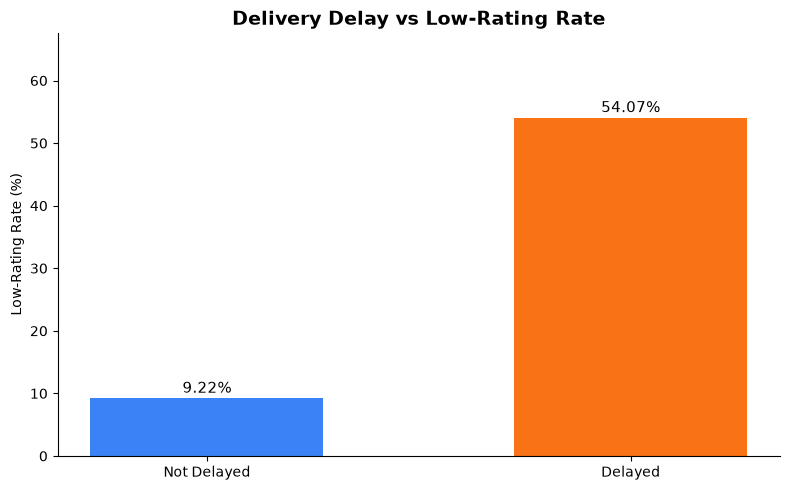

In [21]:
labels = delay_rating_summary.index.tolist()

rates = (
    delay_rating_summary["low_rating_rate"]
    .to_numpy() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    rates,
    color=["#3B82F6", "#F97316"],
    width=0.55
)

for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "Delivery Delay vs Low-Rating Rate",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Low-Rating Rate (%)")
ax.set_ylim(0, max(5, rates.max() * 1.25))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
contingency_table = pd.crosstab(
    analysis_df["is_delayed"],
    analysis_df["low_rating"]
)

contingency_table = contingency_table.reindex(
    index=[0, 1],
    columns=[0, 1],
    fill_value=0
)

contingency_table.index = [
    "Not Delayed",
    "Delayed"
]

contingency_table.columns = [
    "Not Low Rating",
    "Low Rating"
]

display(contingency_table)

,Not Low Rating,Low Rating
Not Delayed,80033,8130
Delayed,3519,4142


In [23]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table,
    correction=False
)

print("Chi-square statistic:", round(chi2, 4))
print("Degrees of freedom:", dof)
print("P-value:", f"{p_value:.6g}")

print("Minimum expected frequency:", expected.min())

Chi-square statistic: 12693.815
Degrees of freedom: 1
P-value: 0
Minimum expected frequency: 981.1299048255134


In [24]:
a = contingency_table.loc[
    "Delayed", "Low Rating"
]

b = contingency_table.loc[
    "Delayed", "Not Low Rating"
]

c = contingency_table.loc[
    "Not Delayed", "Low Rating"
]

d = contingency_table.loc[
    "Not Delayed", "Not Low Rating"
]

n_late = a + b
n_on_time = c + d

late_rate = a / n_late
on_time_rate = c / n_on_time

# 风险差
risk_difference = late_rate - on_time_rate

# 2x2统计表
table_2x2 = Table2x2(
    np.array([
        [a, b],
        [c, d]
    ])
)

# 风险比及95%置信区间
risk_ratio = table_2x2.riskratio
rr_ci_low, rr_ci_high = (
    table_2x2.riskratio_confint()
)

# 风险差的95%置信区间
rd_ci_low, rd_ci_high = (
    confint_proportions_2indep(
        count1=a,
        nobs1=n_late,
        count2=c,
        nobs2=n_on_time,
        compare="diff",
        method="newcomb"
    )
)

print(f"Not Delayed Low-Rating Rate: {on_time_rate:.2%}")
print(f"Delayed Low-Rating Rate: {late_rate:.2%}")

print(
    f"Risk Difference: "
    f"{risk_difference * 100:.2f} percentage points"
)

print(
    f"95% CI for Risk Difference: "
    f"[{rd_ci_low * 100:.2f}, "
    f"{rd_ci_high * 100:.2f}] pp"
)

print(f"Risk Ratio: {risk_ratio:.3f}")

print(
    f"95% CI for Risk Ratio: "
    f"[{rr_ci_low:.3f}, {rr_ci_high:.3f}]"
)

Not Delayed Low-Rating Rate: 9.22%
Delayed Low-Rating Rate: 54.07%
Risk Difference: 44.84 percentage points
95% CI for Risk Difference: [43.71, 45.97] pp
Risk Ratio: 5.863
95% CI for Risk Ratio: [5.694, 6.037]


In [26]:

# 1. 创建分析数据副本
model_df = df.copy()

# 2. 地区样本量
state_counts = model_df["customer_state"].value_counts()

model_df["state_group"] = (
    model_df["customer_state"].where(
        model_df["customer_state"].map(state_counts) >= 100,
        "Other States"
    )
)

# 3. 月份样本量
month_counts = (
    model_df["purchase_year_month"].value_counts()
)

model_df["month_group"] = (
    model_df["purchase_year_month"].where(
        model_df["purchase_year_month"].map(month_counts) >= 100,
        "Sparse Months"
    )
)

# 4. 查看分组结果
print("州分组数量:", model_df["state_group"].nunique())
print("月份分组数量:", model_df["month_group"].nunique())

display(
    model_df["month_group"]
    .value_counts()
    .sort_index()
)


州分组数量: 25
月份分组数量: 22


month_group
Apr-17           2303
Apr-18           6798
Aug-17           4193
Aug-18           6351
Dec-17           5513
Feb-17           1653
Feb-18           6555
Jan-17            750
Jan-18           7069
Jul-17           3872
Jul-18           6159
Jun-17           3135
Jun-18           6099
Mar-17           2546
Mar-18           7003
May-17           3546
May-18           6749
Nov-17           7289
Oct-16            265
Oct-17           4478
Sep-17           4150
Sparse Months       2
Name: count, dtype: int64

In [30]:
print("model_df 的全部字段：")
print(model_df.columns.tolist())

print("\ndf 的全部字段：")
print(df.columns.tolist())

model_df 的全部字段：
['order_id', 'customer_unique_id', 'purchase_date', 'purchase_year_month', 'customer_state', 'merchandise_gmv', 'freight_value', 'item_count', 'distinct_seller_count', 'delivery_days', 'delay_days', 'is_delayed', 'review_score', 'state_group', 'month_group']

df 的全部字段：
['order_id', 'customer_unique_id', 'purchase_date', 'purchase_year_month', 'customer_state', 'merchandise_gmv', 'freight_value', 'item_count', 'distinct_seller_count', 'delivery_days', 'delay_days', 'is_delayed', 'review_score']


In [33]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 将评分和配送延迟变量转换为数值
model_df["review_score"] = pd.to_numeric(
    model_df["review_score"],
    errors="coerce"
)

model_df["is_delayed"] = pd.to_numeric(
    model_df["is_delayed"],
    errors="coerce"
)

# 2. 删除关键变量缺失的记录
model_df = model_df.dropna(
    subset=["review_score", "is_delayed"]
).copy()

# 3. 保留有效评分和二分类延迟变量
model_df = model_df[
    model_df["review_score"].between(1, 5)
    & model_df["is_delayed"].isin([0, 1])
].copy()

# 4. 创建低评分变量
# 1-2星 = 1，3-5星 = 0
model_df["low_rating"] = (
    model_df["review_score"] <= 2
).astype(int)

# 5. 检查变量
print("建模样本量:", len(model_df))

print("\n低评分分布:")
print(model_df["low_rating"].value_counts())

print("\n配送延迟分布:")
print(model_df["is_delayed"].value_counts())

# 6. 建立 Logistic 回归模型
model_1 = smf.glm(
    formula="low_rating ~ is_delayed",
    data=model_df,
    family=sm.families.Binomial()
).fit()

# 7. 输出回归结果
print(model_1.summary())

# 8. 计算 OR 值及95%置信区间
or_table = pd.DataFrame({
    "OR": np.exp(model_1.params),
    "CI_lower": np.exp(model_1.conf_int()[0]),
    "CI_upper": np.exp(model_1.conf_int()[1]),
    "P_value": model_1.pvalues
})

print("\nOdds Ratio Results:")
display(or_table)


建模样本量: 95824

低评分分布:
low_rating
0    83552
1    12272
Name: count, dtype: int64

配送延迟分布:
is_delayed
0    88163
1     7661
Name: count, dtype: int64
                 Generalized Linear Model Regression Results                  
Dep. Variable:             low_rating   No. Observations:                95824
Model:                            GLM   Df Residuals:                    95822
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32407.
Date:                Thu, 08 Oct 2026   Deviance:                       64814.
Time:                        22:55:48   Pearson chi2:                 9.58e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08517
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0

,OR,CI_lower,CI_upper,P_value
Intercept,0.101583,0.099292,0.103927,0.0
is_delayed,11.586957,11.017510,12.185835,0.0


In [37]:
# =====================================================
# 18.5.1 准备多变量 Logistic 回归数据
# =====================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 从原始订单级数据重新建立模型数据
required_columns = [
    "order_id",
    "customer_unique_id",
    "review_score",
    "is_delayed",
    "merchandise_gmv",
    "freight_value",
    "item_count",
    "distinct_seller_count",
    "customer_state",
    "purchase_year_month"
]

# 检查字段是否齐全
missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        f"原始数据缺少字段：{missing_columns}"
    )

model_df = df[required_columns].copy()

# 2. 数值字段转换
numeric_columns = [
    "review_score",
    "is_delayed",
    "merchandise_gmv",
    "freight_value",
    "item_count",
    "distinct_seller_count"
]

for col in numeric_columns:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

# 3. 删除建模必需字段缺失的记录
model_df = model_df.dropna(
    subset=[
        "order_id",
        "customer_unique_id",
        "review_score",
        "is_delayed",
        "merchandise_gmv",
        "freight_value",
        "item_count",
        "distinct_seller_count",
        "purchase_year_month"
    ]
).copy()

# 4. 保留合法取值
model_df = model_df[
    model_df["review_score"].isin([1, 2, 3, 4, 5])
    & model_df["is_delayed"].isin([0, 1])
    & (model_df["merchandise_gmv"] >= 0)
    & (model_df["freight_value"] >= 0)
    & (model_df["item_count"] > 0)
    & (model_df["distinct_seller_count"] > 0)
].copy()

# 5. 重新创建因变量
model_df["low_rating"] = (
    model_df["review_score"].isin([1, 2])
).astype(int)

model_df["is_delayed"] = (
    model_df["is_delayed"].astype(int)
)

# 6. 处理地区缺失
model_df["customer_state"] = (
    model_df["customer_state"]
    .fillna("Unknown")
    .astype(str)
)

model_df["purchase_year_month"] = (
    model_df["purchase_year_month"].astype(str)
)

# 7. 创建金额的对数变量
model_df["log_gmv"] = np.log1p(
    model_df["merchandise_gmv"]
)

model_df["log_freight"] = np.log1p(
    model_df["freight_value"]
)

# 8. 检查订单粒度
assert model_df["order_id"].is_unique, (
    "建模数据存在重复 order_id"
)

print("多变量建模基础样本量：", len(model_df))

print("\n低评分分布：")
print(model_df["low_rating"].value_counts())

print("\n延迟分布：")
print(model_df["is_delayed"].value_counts())

print("\n字段：")
print(model_df.columns.tolist())

多变量建模基础样本量： 95824

低评分分布：
low_rating
0    83552
1    12272
Name: count, dtype: int64

延迟分布：
is_delayed
0    88163
1     7661
Name: count, dtype: int64

字段：
['order_id', 'customer_unique_id', 'review_score', 'is_delayed', 'merchandise_gmv', 'freight_value', 'item_count', 'distinct_seller_count', 'customer_state', 'purchase_year_month', 'low_rating', 'log_gmv', 'log_freight']


In [38]:
# =====================================================
# 18.5.2 地区和月份处理
# =====================================================

# 1. 地区分组
state_counts = (
    model_df["customer_state"].value_counts()
)

model_df["state_group"] = (
    model_df["customer_state"].where(
        model_df["customer_state"].map(state_counts) >= 100,
        "Other States"
    )
)

# 2. 识别低样本月份
month_counts = (
    model_df["purchase_year_month"].value_counts()
)

# 初步调整模型排除样本量少于100的月份
# 避免把相隔很久的极稀疏月份合并成一个时间类别
valid_months = month_counts[
    month_counts >= 100
].index

before_count = len(model_df)

model_df = model_df[
    model_df["purchase_year_month"].isin(valid_months)
].copy()

model_df["month_group"] = (
    model_df["purchase_year_month"].astype(str)
)

model_df["state_group"] = (
    model_df["state_group"].astype(str)
)

# 3. 重置索引
model_df = model_df.reset_index(drop=True)

print("剔除的低样本月份订单数：",
      before_count - len(model_df))

print("最终建模样本量：", len(model_df))

print("地区分组数量：",
      model_df["state_group"].nunique())

print("月份分组数量：",
      model_df["month_group"].nunique())

print("\n月份分布：")
display(
    model_df["month_group"]
    .value_counts()
    .sort_index()
)

剔除的低样本月份订单数： 2
最终建模样本量： 95822
地区分组数量： 25
月份分组数量： 21

月份分布：


month_group
Apr-17    2290
Apr-18    6752
Aug-17    4165
Aug-18    6330
Dec-17    5461
Feb-17    1643
Feb-18    6507
Jan-17     741
Jan-18    7013
Jul-17    3842
Jul-18    6118
Jun-17    3111
Jun-18    6072
Mar-17    2527
Mar-18    6948
May-17    3517
May-18    6722
Nov-17    7237
Oct-16     262
Oct-17    4446
Sep-17    4118
Name: count, dtype: int64

In [39]:
# 检查地区中两种评分结果的样本量
state_check = (
    model_df
    .groupby("state_group")["low_rating"]
    .agg(
        orders="count",
        low_rating_orders="sum"
    )
)

state_check["other_orders"] = (
    state_check["orders"]
    - state_check["low_rating_orders"]
)

# 检查月份
month_check = (
    model_df
    .groupby("month_group")["low_rating"]
    .agg(
        orders="count",
        low_rating_orders="sum"
    )
)

month_check["other_orders"] = (
    month_check["orders"]
    - month_check["low_rating_orders"]
)

print("地区检查：")
display(state_check)

print("\n月份检查：")
display(month_check)

problem_states = state_check[
    (state_check["low_rating_orders"] == 0)
    | (state_check["other_orders"] == 0)
]

problem_months = month_check[
    (month_check["low_rating_orders"] == 0)
    | (month_check["other_orders"] == 0)
]

print("\n可能存在完全分离的地区：")
display(problem_states)

print("\n可能存在完全分离的月份：")
display(problem_months)

地区检查：


,orders,low_rating_orders,other_orders
state_group,,,
AL,394,84,310
AM,144,19,125
BA,3229,549,2680
CE,1273,218,1055
DF,2070,274,1796
ES,1969,272,1697
GO,1946,256,1690
MA,712,142,570
MG,11285,1326,9959



月份检查：


,orders,low_rating_orders,other_orders
month_group,,,
Apr-17,2290,296,1994
Apr-18,6752,796,5956
Aug-17,4165,391,3774
Aug-18,6330,604,5726
Dec-17,5461,788,4673
Feb-17,1643,182,1461
Feb-18,6507,1261,5246
Jan-17,741,89,652
Jan-18,7013,961,6052



可能存在完全分离的地区：


,orders,low_rating_orders,other_orders
state_group,,,



可能存在完全分离的月份：


,orders,low_rating_orders,other_orders
month_group,,,


In [40]:
# =====================================================
# 18.5.3 模型1：未调整 Logistic 回归
# =====================================================

model_1 = smf.glm(
    formula="low_rating ~ is_delayed",
    data=model_df,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": model_df["customer_unique_id"].astype(str)
    }
)

print("Model 1：未调整 Logistic 回归")
print(model_1.summary())

Model 1：未调整 Logistic 回归
                 Generalized Linear Model Regression Results                  
Dep. Variable:             low_rating   No. Observations:                95822
Model:                            GLM   Df Residuals:                    95820
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32406.
Date:                Thu, 08 Oct 2026   Deviance:                       64812.
Time:                        23:13:27   Pearson chi2:                 9.58e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08514
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2869      0

In [41]:
# =====================================================
# 18.5.4 模型2：多变量 Logistic 回归
# =====================================================

formula_2 = """
low_rating ~ is_delayed
           + log_gmv
           + log_freight
           + item_count
           + distinct_seller_count
           + C(state_group)
           + C(month_group)
"""

model_2 = smf.glm(
    formula=formula_2,
    data=model_df,
    family=sm.families.Binomial()
).fit(
    maxiter=100,
    cov_type="cluster",
    cov_kwds={
        "groups": model_df["customer_unique_id"].astype(str)
    }
)

print("Model 2：多变量 Logistic 回归")
print(model_2.summary())

print("\n模型是否收敛：", model_2.converged)

print("模型1样本量：", model_1.nobs)
print("模型2样本量：", model_2.nobs)

Model 2：多变量 Logistic 回归
                 Generalized Linear Model Regression Results                  
Dep. Variable:             low_rating   No. Observations:                95822
Model:                            GLM   Df Residuals:                    95772
Model Family:                Binomial   Df Model:                           49
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31083.
Date:                Thu, 08 Oct 2026   Deviance:                       62165.
Time:                        23:13:45   Pearson chi2:                 9.63e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1101
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [42]:
# =====================================================
# 18.5.5 OR 与95%置信区间对比
# =====================================================

def extract_or(model, model_name, variable="is_delayed"):

    coef = model.params[variable]

    ci = model.conf_int().loc[variable]

    return {
        "Model": model_name,
        "OR": np.exp(coef),
        "CI_Lower": np.exp(ci.iloc[0]),
        "CI_Upper": np.exp(ci.iloc[1]),
        "P_Value": model.pvalues[variable]
    }


or_results = pd.DataFrame([
    extract_or(model_1, "Unadjusted"),
    extract_or(model_2, "Adjusted")
])

display(or_results.round(4))

,Model,OR,CI_Lower,CI_Upper,P_Value
0,Unadjusted,11.5840,11.0135,12.1840,0.0
1,Adjusted,11.7586,11.1427,12.4086,0.0


In [43]:
# =====================================================
# 18.5.6 模型标准化预测概率
# =====================================================

# 保留其他变量不变
scenario_0 = model_df.copy()
scenario_1 = model_df.copy()

# 情景0：全部设为未延迟
scenario_0["is_delayed"] = 0

# 情景1：全部设为延迟
scenario_1["is_delayed"] = 1

# 分别预测
pred_0 = model_2.predict(scenario_0)
pred_1 = model_2.predict(scenario_1)

# 平均预测概率
adjusted_rate_0 = pred_0.mean()
adjusted_rate_1 = pred_1.mean()

# 调整后的概率差
adjusted_diff = adjusted_rate_1 - adjusted_rate_0

print(
    "模型标准化低评分率（未延迟）：",
    f"{adjusted_rate_0:.2%}"
)

print(
    "模型标准化低评分率（延迟）：",
    f"{adjusted_rate_1:.2%}"
)

print(
    "模型标准化低评分率差异：",
    f"{adjusted_diff * 100:.2f} 个百分点"
)

模型标准化低评分率（未延迟）： 9.26%
模型标准化低评分率（延迟）： 52.10%
模型标准化低评分率差异： 42.83 个百分点


In [44]:
# =====================================================
# 18.6.1 模型有效性检查
# =====================================================

import numpy as np
import pandas as pd

# 1. 检查模型是否收敛
print("Model 1 收敛:", model_1.converged)
print("Model 2 收敛:", model_2.converged)

# 2. 检查样本量
print("\nModel 1 样本量:", model_1.nobs)
print("Model 2 样本量:", model_2.nobs)
print("model_df 样本量:", len(model_df))

# 3. 检查回归系数和标准误
print("\nModel 2 是否存在非有限系数:",
      (~np.isfinite(model_2.params)).sum())

print("Model 2 是否存在非有限标准误:",
      (~np.isfinite(model_2.bse)).sum())

# 4. 检查预测概率
pred_prob = model_2.predict(model_df)

print("\n预测概率最小值:", pred_prob.min())
print("预测概率最大值:", pred_prob.max())

# 5. 输出主要模型指标
model_check = pd.DataFrame({
    "Model": ["Model 1", "Model 2"],
    "Observations": [model_1.nobs, model_2.nobs],
    "AIC": [model_1.aic, model_2.aic],
    "Log_Likelihood": [model_1.llf, model_2.llf],
    "Converged": [
        model_1.converged,
        model_2.converged
    ]
})

display(model_check.round(4))

Model 1 收敛: True
Model 2 收敛: True

Model 1 样本量: 95822
Model 2 样本量: 95822
model_df 样本量: 95822

Model 2 是否存在非有限系数: 0
Model 2 是否存在非有限标准误: 0

预测概率最小值: 0.02513811413875592
预测概率最大值: 0.9996952918524703


,Model,Observations,AIC,Log_Likelihood,Converged
0,Model 1,95822,64816.1420,-32406.0710,True
1,Model 2,95822,62265.4275,-31082.7138,True


有评分且延迟标记有效的订单： 95824
延迟天数缺失： 0
延迟标记与延迟天数不一致的订单： 1280


,order_id,is_delayed,delay_days
34,8563039e855156e48fccee4d611a3196,1.0,0.0
148,1d067305b599c1e0dceb3864056ea527,1.0,0.0
220,c82a457d646f77c8f151e12a3e517ed2,1.0,0.0
261,2c3a5e5f5bc3ae78ed5748461e62d47d,1.0,0.0
345,6cc4eb51469dec50a6130fe1cd07b7f9,1.0,0.0
372,5342acb7b183acec77f59e4d78f7c804,1.0,0.0
390,884b1394fc8888e6a877df86eb19e74c,1.0,0.0
634,2f4545bda1b1c794a9a35a3fbe4257ba,1.0,0.0
728,1a4cc55b483d875e3b8bbd64a1b31bba,1.0,0.0
737,ed24759a0ae96582e88fdca0c0997d22,1.0,0.0



各延迟程度组的低评分率：


,delay_severity,orders,low_rating_orders,avg_review_score,low_rating_rate,CI_Lower,CI_Upper
0,Not Late,89443,8289,4.29,9.27,9.08,9.46
1,1-3 Days,1852,595,3.29,32.13,30.04,34.29
2,4-7 Days,1748,1183,2.10,67.68,65.45,69.83
3,8-14 Days,1446,1159,1.67,80.15,78.02,82.13
4,15+ Days,1335,1046,1.72,78.35,76.06,80.48


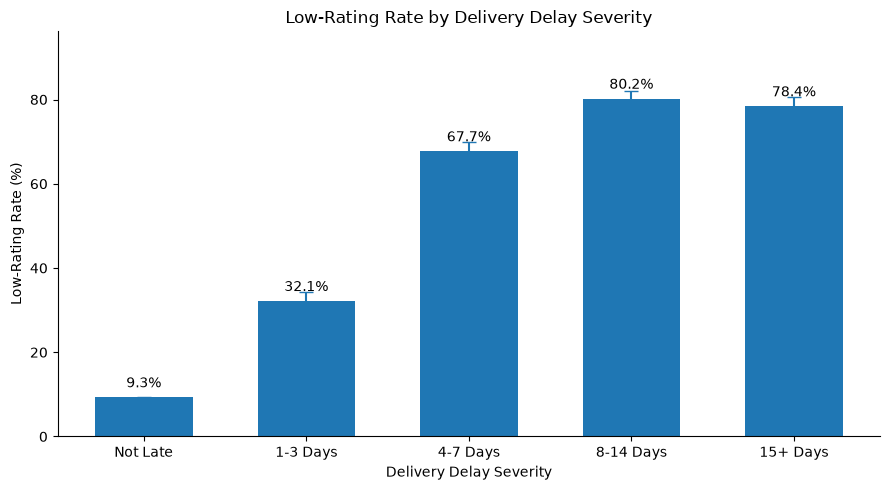


延迟严重程度回归样本量： 95822

模型是否收敛： True

不同延迟程度的调整后 OR：


,Delay Group,Adjusted OR,CI Lower,CI Upper,P-value
0,1-3 Days,4.8436,4.3671,5.3721,0.0
1,4-7 Days,21.4733,19.3209,23.8655,0.0
2,8-14 Days,39.8957,34.8926,45.6161,0.0
3,15+ Days,33.3240,29.0828,38.1837,0.0



分析完成。


In [47]:
# ============================================================
# 18.6 延迟严重程度与低评分风险分析
# 独立运行模块：不依赖 model_1、model_2、or_results
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.proportion import proportion_confint


# ============================================================
# 1. 读取原始数据
# ============================================================

# 如果 Notebook 中已经有 df，就直接使用
source_df = globals().get("df", None)

# 如果 Kernel 重启、df 不存在，则重新读取 CSV
if not isinstance(source_df, pd.DataFrame):

    possible_paths = [
        Path("../data/processed/delivery_review_orders.csv"),
        Path("data/processed/delivery_review_orders.csv")
    ]

    csv_path = next(
        (p for p in possible_paths if p.exists()),
        None
    )

    if csv_path is None:
        raise FileNotFoundError(
            "找不到 delivery_review_orders.csv，"
            "请检查 data/processed/ 文件夹。"
        )

    source_df = pd.read_csv(csv_path, low_memory=False)


# ============================================================
# 2. 检查需要的字段
# ============================================================

required_columns = [
    "order_id",
    "customer_unique_id",
    "review_score",
    "is_delayed",
    "delay_days",
    "merchandise_gmv",
    "freight_value",
    "item_count",
    "distinct_seller_count",
    "customer_state",
    "purchase_year_month"
]

missing_columns = [
    col for col in required_columns
    if col not in source_df.columns
]

if missing_columns:
    raise ValueError(
        f"数据缺少以下字段：{missing_columns}"
    )


# ============================================================
# 3. 创建分析数据
# ============================================================

severity_df = source_df[required_columns].copy()

numeric_columns = [
    "review_score",
    "is_delayed",
    "delay_days",
    "merchandise_gmv",
    "freight_value",
    "item_count",
    "distinct_seller_count"
]

for col in numeric_columns:
    severity_df[col] = pd.to_numeric(
        severity_df[col],
        errors="coerce"
    )

# 只保留有有效评分和有效延迟标记的订单
severity_df = severity_df[
    severity_df["review_score"].isin([1, 2, 3, 4, 5])
    & severity_df["is_delayed"].isin([0, 1])
].copy()

print("有评分且延迟标记有效的订单：", len(severity_df))

# 延迟天数缺失时，无法做严重程度分组
missing_delay_days = severity_df["delay_days"].isna().sum()

print("延迟天数缺失：", missing_delay_days)

severity_df = severity_df.dropna(
    subset=["delay_days"]
).copy()

# 创建低评分变量
severity_df["low_rating"] = (
    severity_df["review_score"].isin([1, 2])
).astype(int)


# ============================================================
# 4. 检查延迟标记与延迟天数的一致性
# ============================================================

severity_df["delayed_from_days"] = (
    severity_df["delay_days"] > 0
).astype(int)

mismatch_count = (
    severity_df["delayed_from_days"]
    != severity_df["is_delayed"]
).sum()

print("延迟标记与延迟天数不一致的订单：", mismatch_count)

# 如果不为0，先保留记录，输出样例供检查
if mismatch_count > 0:

    display(
        severity_df.loc[
            severity_df["delayed_from_days"]
            != severity_df["is_delayed"],
            [
                "order_id",
                "is_delayed",
                "delay_days"
            ]
        ].head(10)
    )


# ============================================================
# 5. 创建延迟程度分组
# ============================================================

severity_labels = [
    "Not Late",
    "1-3 Days",
    "4-7 Days",
    "8-14 Days",
    "15+ Days"
]

severity_df["delay_severity"] = pd.cut(
    severity_df["delay_days"],
    bins=[
        -np.inf,
        0,
        3,
        7,
        14,
        np.inf
    ],
    labels=severity_labels,
    right=True,
    ordered=True
)

# 注意：严重程度按 delay_days 定义。
# 若第4步出现不一致订单，需要先核对 SQL 口径，
# 再解释它与 is_delayed 二分类分析的差别。


# ============================================================
# 6. 计算各组低评分率
# ============================================================

severity_summary = (
    severity_df
    .groupby("delay_severity", observed=True)
    .agg(
        orders=("order_id", "nunique"),
        low_rating_orders=("low_rating", "sum"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

severity_summary["low_rating_rate"] = (
    severity_summary["low_rating_orders"]
    / severity_summary["orders"]
)

# Wilson 95%置信区间
ci_lower, ci_upper = proportion_confint(
    count=severity_summary["low_rating_orders"].to_numpy(),
    nobs=severity_summary["orders"].to_numpy(),
    alpha=0.05,
    method="wilson"
)

severity_summary["CI_Lower"] = ci_lower
severity_summary["CI_Upper"] = ci_upper

# 输出百分比形式
display_table = severity_summary.copy()

for col in [
    "low_rating_rate",
    "CI_Lower",
    "CI_Upper"
]:
    display_table[col] = (
        display_table[col] * 100
    )

print("\n各延迟程度组的低评分率：")

display(display_table.round(2))


# ============================================================
# 7. 绘制低评分率及95%置信区间
# ============================================================

plot_data = severity_summary.copy()

rates = plot_data["low_rating_rate"].to_numpy() * 100

lower_errors = (
    plot_data["low_rating_rate"]
    - plot_data["CI_Lower"]
).to_numpy() * 100

upper_errors = (
    plot_data["CI_Upper"]
    - plot_data["low_rating_rate"]
).to_numpy() * 100

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_data["delay_severity"].astype(str),
    rates,
    width=0.6
)

ax.errorbar(
    x=np.arange(len(rates)),
    y=rates,
    yerr=[lower_errors, upper_errors],
    fmt="none",
    capsize=5
)

for i, rate in enumerate(rates):
    ax.text(
        i,
        rate + max(rates) * 0.03,
        f"{rate:.1f}%",
        ha="center"
    )

ax.set_title(
    "Low-Rating Rate by Delivery Delay Severity"
)

ax.set_xlabel("Delivery Delay Severity")
ax.set_ylabel("Low-Rating Rate (%)")

ax.set_ylim(
    0,
    max(10, max(rates) * 1.2)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 8. 准备调整后的 Logistic 回归数据
# ============================================================

reg_df = severity_df.copy()

reg_df = reg_df.dropna(
    subset=[
        "customer_unique_id",
        "merchandise_gmv",
        "freight_value",
        "item_count",
        "distinct_seller_count",
        "purchase_year_month"
    ]
).copy()

reg_df = reg_df[
    (reg_df["merchandise_gmv"] >= 0)
    & (reg_df["freight_value"] >= 0)
    & (reg_df["item_count"] > 0)
    & (reg_df["distinct_seller_count"] > 0)
].copy()

reg_df["customer_state"] = (
    reg_df["customer_state"]
    .fillna("Unknown")
    .astype(str)
)

reg_df["purchase_year_month"] = (
    reg_df["purchase_year_month"].astype(str)
)

# 排除不足100单的月份
month_counts = reg_df[
    "purchase_year_month"
].value_counts()

valid_months = month_counts[
    month_counts >= 100
].index

reg_df = reg_df[
    reg_df["purchase_year_month"].isin(valid_months)
].copy()

reg_df["month_group"] = reg_df["purchase_year_month"]

# 地区样本量分组
state_counts = reg_df["customer_state"].value_counts()

reg_df["state_group"] = (
    reg_df["customer_state"].where(
        reg_df["customer_state"].map(state_counts) >= 100,
        "Other States"
    )
)

# 金额对数变换
reg_df["log_gmv"] = np.log1p(
    reg_df["merchandise_gmv"]
)

reg_df["log_freight"] = np.log1p(
    reg_df["freight_value"]
)

reg_df = reg_df.reset_index(drop=True)

print("\n延迟严重程度回归样本量：", len(reg_df))


# ============================================================
# 9. 多变量 Logistic 回归
# ============================================================

severity_formula = """
low_rating ~ C(
    delay_severity,
    Treatment(reference="Not Late")
)
+ log_gmv
+ log_freight
+ item_count
+ distinct_seller_count
+ C(state_group)
+ C(month_group)
"""

severity_model = smf.glm(
    formula=severity_formula,
    data=reg_df,
    family=sm.families.Binomial()
).fit(
    maxiter=100,
    cov_type="cluster",
    cov_kwds={
        "groups": reg_df["customer_unique_id"].astype(str)
    }
)

print("\n模型是否收敛：", severity_model.converged)


# ============================================================
# 10. 提取各延迟组的调整后 OR
# ============================================================

model_ci = severity_model.conf_int()

or_rows = []

for term in severity_model.params.index:

    if not term.startswith("C(delay_severity"):
        continue

    group_name = term.split("[T.")[-1].rstrip("]")

    or_rows.append({
        "Delay Group": group_name,
        "Adjusted OR": np.exp(
            severity_model.params[term]
        ),
        "CI Lower": np.exp(
            model_ci.loc[term, 0]
        ),
        "CI Upper": np.exp(
            model_ci.loc[term, 1]
        ),
        "P-value": severity_model.pvalues[term]
    })

severity_or_table = pd.DataFrame(or_rows)

print("\n不同延迟程度的调整后 OR：")

display(severity_or_table.round(4))

print("\n分析完成。")